In [48]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import keras
import keras_nlp
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from catboost import Pool

In [3]:
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt')

In [4]:
# load json files
human_listings_ag = pd.read_json("scraping/agricultural/human_listings.json")
ai_listings_ag = pd.read_json("scraping/agricultural/ai_listings.json")

# add source_model column to human listings
human_listings_ag["source_model"] = "human"

# combine datasets
combined_listings_ag = pd.concat([human_listings_ag, ai_listings_ag], ignore_index=True)

# encode target variable
# Human = 0, AI = 1
combined_listings_ag["target"] = combined_listings_ag["label"].map({"Human": 0, "AI": 1})

# combine text features (name + description)
combined_listings_ag["full_text"] = combined_listings_ag["name"].fillna("") + " - " + combined_listings_ag["description"].fillna("")

# drop unused columns
combined_listings_ag_clean = combined_listings_ag.drop(columns=["id", "url", "name", "description", "label"])

In [5]:
combined_listings_ag_clean

,source_model,target,full_text
0,human,0,Soulful Seeds - Soulful Seeds is a social and ...
1,human,0,"Urban Earth Care Farm - Urban Earth Care Farm,..."
2,human,0,Navarro Farm - The Navarro family 5-acre farm ...
3,human,0,The Farm At Our House - We are committed to su...
4,human,0,Arcadia Farm - Arcadia is a nonprofit organiza...
...,...,...,...
785,openai/gpt-oss-120b,1,Horizon Grove - Nestled in the rolling hills o...
786,openai/gpt-oss-120b,1,Maple Creek Orchard - Located on the gentle ro...
787,openai/gpt-oss-120b,1,Cedar Ridge Farm - Nestled on a 30‑acre histor...
788,openai/gpt-oss-120b,1,Island Roots Project - Located in the heart of...


In [6]:
# load csv file
human_listings_job = pd.read_csv("scraping/jobs/scraped_data.csv")

# clean text function
def clean_text(col):
    return (
        col.astype(str)
        .str.replace(r"(\\n|\n|\r)+", " ", regex=True) # remove all newline variants
        .str.replace(r"\s+", " ", regex=True)          # collapse multiple spaces
        .str.strip()
    )

# clean relevant columns
human_listings_job["job_title"] = clean_text(human_listings_job["job_title"])
human_listings_job["job_summary"] = clean_text(human_listings_job["job_summary"])

# add target variable and source (0 = human)
human_listings_job["target"] = 0
human_listings_job["source_model"] = "human"

# combine text features
human_listings_job["full_text"] = human_listings_job["job_title"].fillna("") + " - " + human_listings_job["job_summary"].fillna("")

# drop unused columns
human_listings_job_clean = human_listings_job.drop(columns=["Unnamed: 0", "job_title", "job_location", "job_salary", "job_summary"])

In [7]:
human_listings_job_clean

,target,source_model,full_text
0,0,human,Data Analytics and Insights Associate - About ...
1,0,human,Data Engineer II - Rocket Lab Rocket Lab is a ...
2,0,human,"Group Manager, Technical Data Science - Workin..."
3,0,human,Senior Data Scientist - Overview Our formula f...
4,0,human,App Store & Arcade Marketing Data Scientist - ...
...,...,...,...
12301,0,human,Technical Staff: Biomedical Deep Learning & Si...
12302,0,human,Senior Statistical Analyst - Job Summary The D...
12303,0,human,"Associate Director, Quality Artificial Intelli..."
12304,0,human,"Research Assistant, Program Development, Monit..."


In [8]:
# load csv file
claude_listings_job = pd.read_csv("scraping/jobs/claude_data.csv")

# add target and source (1 = AI)
claude_listings_job["target"] = 1
claude_listings_job["source_model"] = "claude"

# combine text features
claude_listings_job["full_text"] = claude_listings_job["job_title"].fillna("") + " - " + claude_listings_job["job_summary"].fillna("")

# drop unused columns
claude_listings_job_clean = claude_listings_job.drop(columns=["job_title", "job_location", "job_salary", "job_summary"])

In [9]:
claude_listings_job_clean

,target,source_model,full_text
0,1,claude,NLP Engineer - StratEdge Consulting is a bouti...
1,1,claude,Senior Data Engineer - HorizonMind Analytics i...
2,1,claude,Research Engineer – NLP - Meridian Data Soluti...
3,1,claude,Business Intelligence Analyst - HorizonMind An...
4,1,claude,AI Solutions Architect - Synapse Analytics is ...
...,...,...,...
995,1,claude,Data Engineer - DataBridge Consulting is a pre...
996,1,claude,Senior Data Engineer - StratEdge Consulting is...
997,1,claude,Decision Scientist - Vantage Point AI is an AI...
998,1,claude,Data Intelligence Analyst - TechVision Analyti...


In [10]:
# load csv file
gemini_listings_job = pd.read_csv("scraping/jobs/gemini_data.csv")

# add target and source (1 = AI)
gemini_listings_job["target"] = 1
gemini_listings_job["source_model"] = "gemini"

# combine text features
gemini_listings_job["full_text"] = gemini_listings_job["jobtitle"].fillna("") + " - " + gemini_listings_job["jobsummary"].fillna("")

# drop unused columns
gemini_listings_job_clean = gemini_listings_job.drop(columns=["jobtitle", "joblocation", "jobsalary", "jobsummary"])

In [11]:
gemini_listings_job_clean

,target,source_model,full_text
0,1,gemini,Data Scientist - Quick note: We value curiosit...
1,1,gemini,Sr. Data Scientist - Are you tired of big corp...
2,1,gemini,"Sr. Data Scientist - Looking for a builder, no..."
3,1,gemini,"Staff AI Scientist - Looking for a builder, no..."
4,1,gemini,Machine Learning Engineer (Remote) - We're gro...
...,...,...,...
295,1,gemini,STAFF AI SCIENTIST - We're growing fast and ne...
296,1,gemini,Data Scientist - Are you tired of big corporat...
297,1,gemini,"Sr. Data Scientist - Looking for a builder, no..."
298,1,gemini,Data Analytics Manager - Are you tired of big ...


In [12]:
# load csv file
chatgpt_listings_job = pd.read_csv("scraping/jobs/chatgpt_data.csv")

# add target and source (1 = AI)
chatgpt_listings_job["target"] = 1
chatgpt_listings_job["source_model"] = "chatgpt"

# combine text features
chatgpt_listings_job["full_text"] = chatgpt_listings_job["jobtitle"].fillna("") + " - " + chatgpt_listings_job["jobsummary"].fillna("")

# drop unused columns
chatgpt_listings_job_clean = chatgpt_listings_job.drop(columns=["jobtitle", "joblocation", "jobsalary", "jobsummary"])

In [13]:
chatgpt_listings_job_clean

,target,source_model,full_text
0,1,chatgpt,Senior Data Scientist - Our client is hiring a...
1,1,chatgpt,Senior Data Scientist - This role sits within ...
2,1,chatgpt,ML Engineer - Join a fast-moving team working ...
3,1,chatgpt,Data Science Manager - This role sits within a...
4,1,chatgpt,Data Science Manager - Join a fast-moving team...
...,...,...,...
295,1,chatgpt,ML Engineer - Our client is hiring a Data Scie...
296,1,chatgpt,Senior Data Scientist - This role sits within ...
297,1,chatgpt,Senior Data Scientist - Join a fast-moving tea...
298,1,chatgpt,Data Science Manager - This role sits within a...


In [16]:
# load csv file
copilot_listings_job = pd.read_csv("scraping/jobs/copilot_data.csv")

# add target and source (1 = AI)
copilot_listings_job["target"] = 1
copilot_listings_job["source_model"] = "copilot"

# combine text features
copilot_listings_job["full_text"] = copilot_listings_job["job_title"].fillna("") + " - " + copilot_listings_job["job_summary"].fillna("")

# drop unused columns
copilot_listings_job_clean = copilot_listings_job.drop(columns=["job_title", "job_location", "job_salary", "job_summary"])

In [17]:
copilot_listings_job_clean

,target,source_model,full_text
0,1,copilot,"Senior Data Scientist - We are a growing, inno..."
1,1,copilot,"Applied Scientist, ML - This company operates ..."
2,1,copilot,Principal Data Scientist - This company operat...
3,1,copilot,"Senior Data Scientist - We are a growing, inno..."
4,1,copilot,"Applied Scientist, ML - Our organization is a ..."
...,...,...,...
295,1,copilot,Machine Learning Engineer - Our organization i...
296,1,copilot,Senior Data Scientist - This company operates ...
297,1,copilot,Staff Machine Learning Engineer - Our organiza...
298,1,copilot,"Analytics Scientist - We are a growing, innova..."


In [21]:
# load csv file
perplexity_listings_job = pd.read_csv("scraping/jobs/perplexity_data.csv")

# clean relevant columns
perplexity_listings_job["jobtitle"] = clean_text(perplexity_listings_job["jobtitle"])
perplexity_listings_job["jobsummary"] = clean_text(perplexity_listings_job["jobsummary"])

# add target and source (1 = AI)
perplexity_listings_job["target"] = 1
perplexity_listings_job["source_model"] = "perplexity"

# combine text features
perplexity_listings_job["full_text"] = perplexity_listings_job["jobtitle"].fillna("") + " - " + perplexity_listings_job["jobsummary"].fillna("")

# drop unused columns
perplexity_listings_job_clean = perplexity_listings_job.drop(columns=["jobtitle", "joblocation", "jobsalary", "company", "jobtype", "posted_date", "jobsummary"])

In [22]:
perplexity_listings_job_clean

,target,source_model,full_text
0,1,perplexity,ML Research Scientist - Role Summary: Northbri...
1,1,perplexity,Quantitative Data Scientist - Role Summary: Su...
2,1,perplexity,Data Scientist - Position Overview: Brightline...
3,1,perplexity,Senior Data Scientist - About the Role: Signal...
4,1,perplexity,ML Research Scientist - Role Summary: Northbri...
...,...,...,...
295,1,perplexity,Applied Scientist - Job Summary: Brightline AI...
296,1,perplexity,Analytics Manager - Job Summary: Parallel Orbi...
297,1,perplexity,Senior Data Scientist - Job Summary: Crescent ...
298,1,perplexity,Computer Vision Engineer - Role Summary: Summi...


In [26]:
# undersample human job listings to 1500
human_listings_job_sampled = human_listings_job_clean.sample(n=1500, random_state=1)

# undersample Claude job listings to 300
claude_listings_job_sampled = claude_listings_job_clean.sample(n=300, random_state=1)

# combine all the job datasets 
# (Human: 1500, AI: 300 * 5 models = 1500)
combined_jobs = pd.concat(
    [
        human_listings_job_sampled,
        claude_listings_job_sampled,
        gemini_listings_job_clean,
        chatgpt_listings_job_clean,
        copilot_listings_job_clean,
        perplexity_listings_job_clean
    ], 
    ignore_index=True
)

# combine the balanced jobs dataset with the agricultural dataset
final_combined_listings = pd.concat(
    [combined_listings_ag_clean, combined_jobs], 
    ignore_index=True
)

# perform train-test split (80:20)
X_train_base, X_test_base, y_train, y_test = train_test_split(
    final_combined_listings["full_text"],
    final_combined_listings["target"],
    test_size=0.2,
    random_state=1,
    stratify=final_combined_listings["target"]
)

In [27]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def deep_clean_text(text):
    # convert to lowercase
    text = text.lower()

    # remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # tokenize, remove stopwords, lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # rejoin into single string
    return " ".join(words)

In [28]:
# apply the cleaning function to the train and test splits
X_train_clean = X_train_base.apply(deep_clean_text)
X_test_clean = X_test_base.apply(deep_clean_text)

# convert to DataFrame (Required for CatBoost text features)
X_train_df = pd.DataFrame({'full_text': X_train_clean})
X_test_df = pd.DataFrame({'full_text': X_test_clean})

In [34]:
# initalize CatBoost Classifier
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    loss_function='Logloss', # binary classification
    eval_metric='Accuracy',
    verbose=100
)

# train model
# pass the column name as a list to the text_features parameter
catboost_model.fit(
    X_train_df, 
    y_train, 
    text_features=['full_text'], 
    eval_set=(X_test_df, y_test)
)

0:	learn: 0.9858179	test: 0.9920844	best: 0.9920844 (0)	total: 44.1ms	remaining: 44s
100:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 5.9s	remaining: 52.5s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 11.4s	remaining: 45.3s
300:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 16.9s	remaining: 39.3s
400:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 22.3s	remaining: 33.4s
500:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 27.8s	remaining: 27.7s
600:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 33.2s	remaining: 22.1s
700:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 38.6s	remaining: 16.5s
800:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 44.1s	remaining: 11s
900:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 49.6s	remaining: 5.45s
999:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (21)	total: 54.9s	remaining: 0us

bestTest = 1
bestIteration = 

CatBoostClassifier(eval_metric='Accuracy', iterations=1000, learning_rate=0.1, loss_function='Logloss', verbose=100)

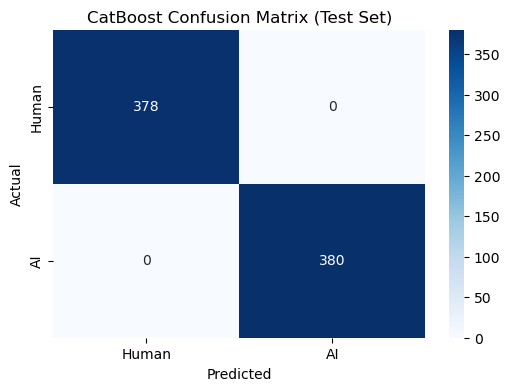


--- CatBoost Results ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       378
      AI (1)       1.00      1.00      1.00       380

    accuracy                           1.00       758
   macro avg       1.00      1.00      1.00       758
weighted avg       1.00      1.00      1.00       758



In [36]:
# predictions and evaluation
catboost_pred = catboost_model.predict(X_test_df)

# confusion matrix
cm = confusion_matrix(y_test, catboost_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human", "AI"], 
            yticklabels=["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix (Test Set)")
plt.show()

# compute and evaluate SVM results
print("\n--- CatBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, catboost_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, catboost_pred, target_names=['Human (0)', 'AI (1)']))

In [31]:
# apply deep cleaning
X_train_svm = X_train_base.apply(deep_clean_text)
X_test_svm = X_test_base.apply(deep_clean_text)

# train TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# fit only on training data, then transform both
X_train_tfidf = tfidf.fit_transform(X_train_svm)
X_test_tfidf = tfidf.transform(X_test_svm)

In [32]:
# initialize the SVM with linear kernel
svm_model = SVC(kernel='linear', random_state=1)

# train the model using the TF-IDF vectorized training data
svm_model.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=1)

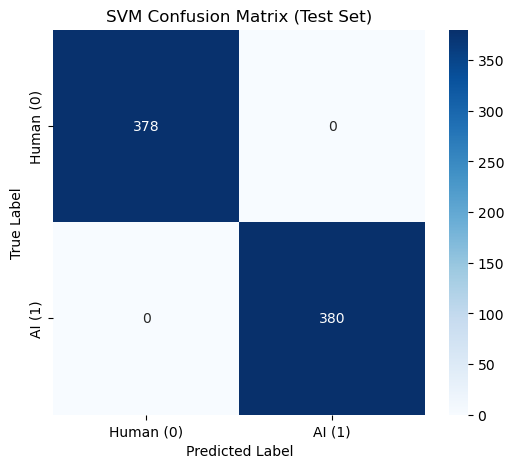


--- SVM Results ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00       378
      AI (1)       1.00      1.00      1.00       380

    accuracy                           1.00       758
   macro avg       1.00      1.00      1.00       758
weighted avg       1.00      1.00      1.00       758



In [33]:
# predict on the test set
svm_preds = svm_model.predict(X_test_tfidf)

# display confusion matrix
conf_matrix = confusion_matrix(y_test, svm_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# compute and evaluate SVM results
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_preds, target_names=['Human (0)', 'AI (1)']))

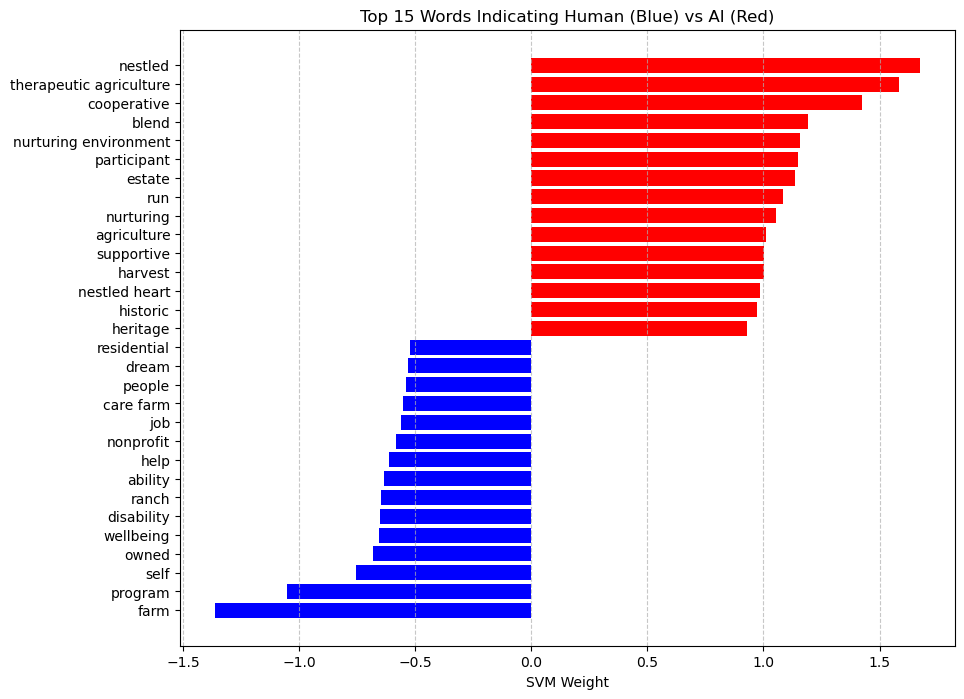

In [37]:
# Extract the coefficients and feature names
coefficients = svm_model.coef_.toarray()[0]
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame of words and their weights
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
})

# Sort by weight
# Negative weights = Human (Class 0), Positive weights = AI (Class 1)
feature_importance = feature_importance.sort_values(by='Weight', ascending=True)

# Get top 15 words for Human and top 15 words for AI
top_human_words = feature_importance.head(15)
top_ai_words = feature_importance.tail(15)

# Combine them for the plot
top_features_combined = pd.concat([top_human_words, top_ai_words])

plt.figure(figsize=(10, 8))
# Color human words blue and AI words red
colors = ['blue' if x < 0 else 'red' for x in top_features_combined['Weight']]
plt.barh(top_features_combined['Feature'], top_features_combined['Weight'], color=colors)

plt.xlabel('SVM Weight')
plt.title('Top 15 Words Indicating Human (Blue) vs AI (Red)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [39]:
def light_clean_text(text):
    # remove HTML tags if present
    text = re.sub(r'<.*?>', '', text)

    # remove extra whitespaces/lines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [40]:
# apply light cleaning
X_train_transformer = X_train_base.apply(light_clean_text).tolist()
X_test_transformer = X_test_base.apply(light_clean_text).tolist()

# create validation set (from the training data)
X_train_transformer, X_val_transformer, y_train_np, y_val_np = train_test_split(
    X_train_transformer, 
    y_train, 
    test_size=0.20,
    random_state=1, 
    stratify=y_train
)

# convert final test labels to numpy array for consistency
y_test_np = np.array(y_test)

In [41]:
# define the pre-trained model
preset = "bert_tiny_en_uncased"

# create preprocessor
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    preset=preset,
    sequence_length=128
)

# create classifier
classifier = keras_nlp.models.BertClassifier.from_preset(
    preset=preset,
    preprocessor=preprocessor,
    num_classes=2
)

# compile classifier
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    metrics=["accuracy"]
)

# display classifier summary
classifier.summary()

Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 128), (None,      │       4,385,920 │ padding_mask[0][0],        │
│                               │ None, 128)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 128)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │             258 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,386,178 (16.73 MB)

 Trainable params: 4,386,178 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# define callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=3, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# fine-tune the BERT model 
history = classifier.fit(
    x=X_train_transformer,
    y=y_train_np,
    validation_data=(X_val_transformer, y_val_np),
    epochs=10,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 43s 228ms/step - accuracy: 0.7226 - loss: 0.6108 - val_accuracy: 0.9720 - val_loss: 0.2158 - learning_rate: 5.0000e-05
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 34s 222ms/step - accuracy: 0.9780 - loss: 0.1656 - val_accuracy: 0.9951 - val_loss: 0.0518 - learning_rate: 5.0000e-05
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 34s 224ms/step - accuracy: 0.9935 - loss: 0.0514 - val_accuracy: 0.9984 - val_loss: 0.0244 - learning_rate: 5.0000e-05
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 34s 224ms/step - accuracy: 0.9934 - loss: 0.0369 - val_accuracy: 0.9885 - val_loss: 0.0412 - learning_rate: 5.0000e-05
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9968 - loss: 0.0155 
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
152/152 ━━━━━━━━━━━━━━━━━━━━ 34s 223ms/step - accuracy: 0.9968 - loss: 0.0155 - val_accuracy: 0.9489 - val_loss: 0.1605 - learning_rate: 5.0000e-05
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 35s 228ms/s

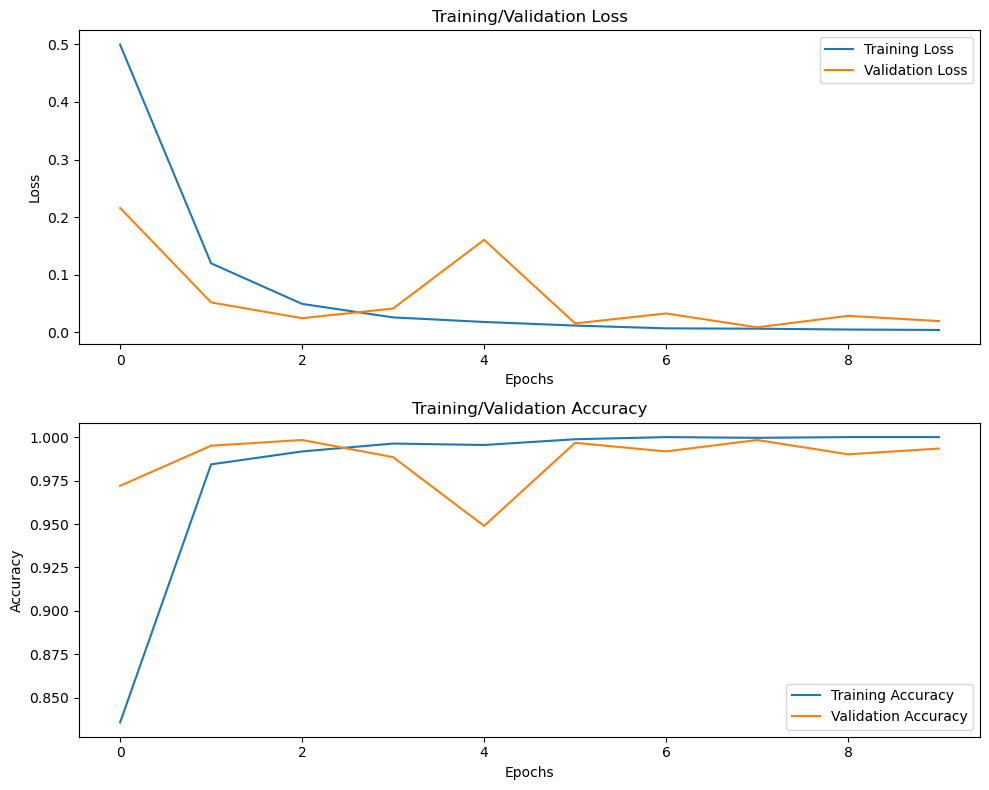

In [43]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], linestyle='-', label='Training Loss')
plt.plot(history.history['val_loss'], linestyle='-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history.history['accuracy'], linestyle='-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linestyle='-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training/Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9903 - loss: 0.0331 
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step 


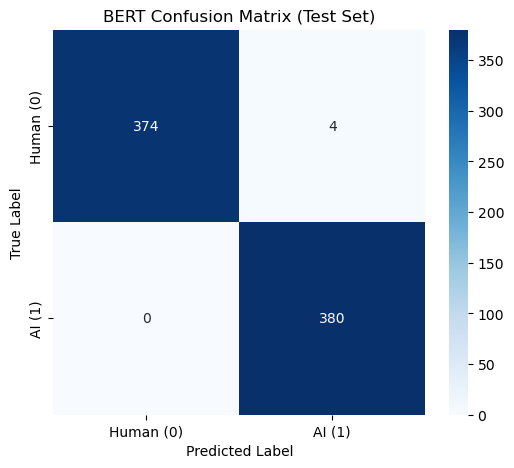


--- BERT Results ---
BERT Test Loss: 0.0253
BERT Test Accuracy: 0.9947

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      0.99      0.99       378
      AI (1)       0.99      1.00      0.99       380

    accuracy                           0.99       758
   macro avg       0.99      0.99      0.99       758
weighted avg       0.99      0.99      0.99       758



In [44]:
# evaluate the fine-tuned BERT model
bert_test_loss, bert_test_accuracy = classifier.evaluate(
    x=X_test_transformer, 
    y=y_test_np, 
    verbose=1
)

# get predictions (these will be logits because from_logits=True)
test_preds = classifier.predict(X_test_transformer)

# convert logits to binary labels using argmax
pred_labels = np.argmax(test_preds, axis=1)

# compute confusion matrix
conf_matrix = confusion_matrix(y_test_np, pred_labels)

# display confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Confusion Matrix (Test Set)")
plt.show()

# Print results
print("\n--- BERT Results ---")
print(f"BERT Test Loss: {bert_test_loss:.4f}")
print(f"BERT Test Accuracy: {bert_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_np, pred_labels, target_names=["Human (0)", "AI (1)"]))

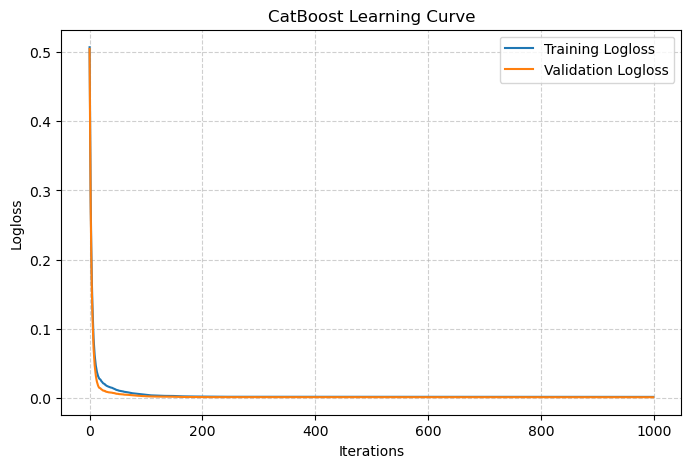

Calculating SHAP values...


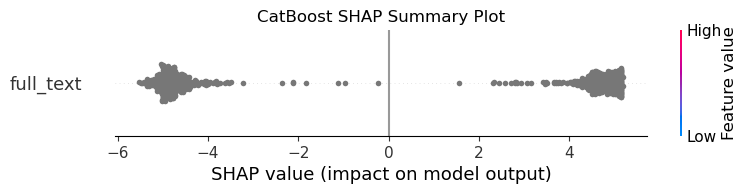

In [49]:
# --- A. CatBoost Learning Curve ---
evals_result = catboost_model.get_evals_result()

plt.figure(figsize=(8, 5))
plt.plot(evals_result['learn']['Logloss'], label='Training Logloss')
plt.plot(evals_result['validation']['Logloss'], label='Validation Logloss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.title('CatBoost Learning Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- B. CatBoost SHAP Summary Plot ---
print("Calculating SHAP values...")
# Create a Pool object required by SHAP for text features
test_pool = Pool(X_test_df, text_features=['full_text'])

# Initialize SHAP explainer and calculate values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(test_pool)

# Plot summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title("CatBoost SHAP Summary Plot")
plt.show()

Running PCA on TF-IDF vectors...


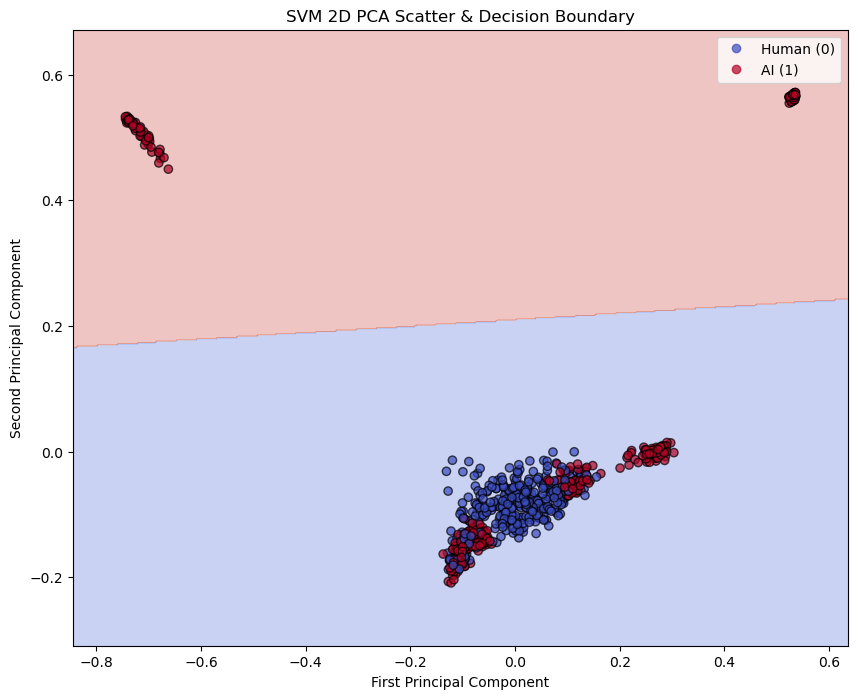

In [50]:
from sklearn.decomposition import PCA
import numpy as np

# --- A. PCA Dimensionality Reduction ---
print("Running PCA on TF-IDF vectors...")
pca = PCA(n_components=2, random_state=42)
# Convert sparse TF-IDF matrix to dense for PCA
X_test_dense = X_test_tfidf.toarray()
X_test_pca = pca.fit_transform(X_test_dense)

# --- B. Train a 2D SVM for Visualization ---
svm_2d = SVC(kernel='linear', random_state=1)
svm_2d.fit(X_test_pca, y_test)

# --- C. Plotting the Decision Boundary ---
plt.figure(figsize=(10, 8))

# Create a mesh grid
x_min, x_max = X_test_pca[:, 0].min() - 0.1, X_test_pca[:, 0].max() + 0.1
y_min, y_max = X_test_pca[:, 1].min() - 0.1, X_test_pca[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Predict across the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw the boundary and background regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

# Scatter the actual test data
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, 
                      cmap="coolwarm", edgecolors='k', alpha=0.7)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('SVM 2D PCA Scatter & Decision Boundary')

# Add legend
legend_elements = scatter.legend_elements()[0]
plt.legend(handles=legend_elements, labels=["Human (0)", "AI (1)"])
plt.show()

Extracting BERT embeddings...
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step 
Running t-SNE to compress embeddings to 2D...


/Users/andy/opt/anaconda3/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


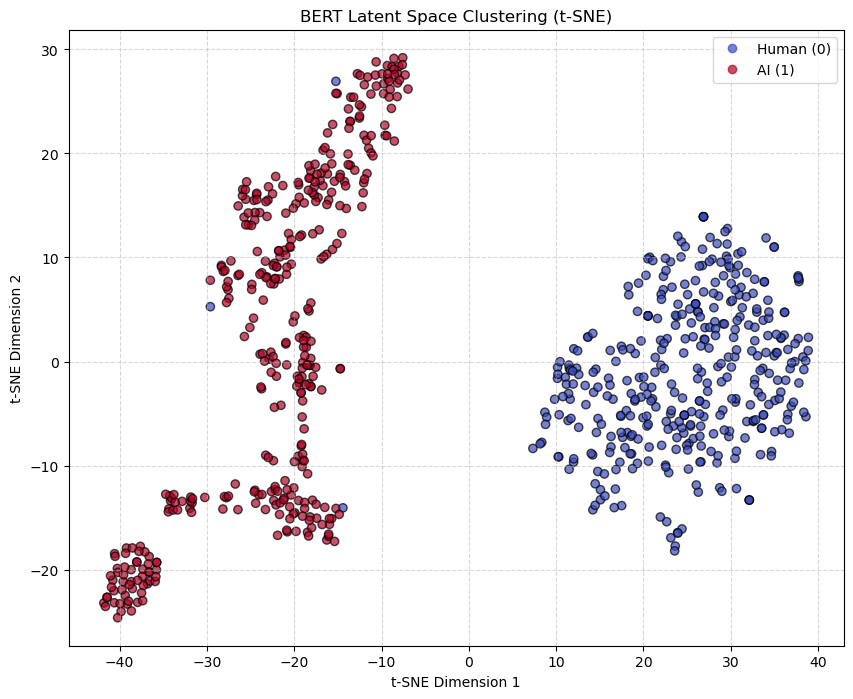

In [51]:
from sklearn.manifold import TSNE
import tensorflow as tf

print("Extracting BERT embeddings...")
# Run the raw text through the preprocessor
processed_inputs = preprocessor(X_test_transformer)

# Pass the processed inputs through the BERT backbone to get embeddings
backbone_outputs = classifier.backbone.predict(processed_inputs)

# Extract the CLS token representation (pooled_output)
embeddings = backbone_outputs['pooled_output']

print("Running t-SNE to compress embeddings to 2D...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plotting the Latent Space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=y_test_np, 
                      cmap='coolwarm', edgecolors='k', alpha=0.7)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('BERT Latent Space Clustering (t-SNE)')

legend_elements = scatter.legend_elements()[0]
plt.legend(handles=legend_elements, labels=["Human (0)", "AI (1)"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()